<a href="https://colab.research.google.com/github/ademimi2008/spam_task/blob/main/spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
TP, FN, FP, TN = 51, 24, 7, 168
total = TP + FN + FP + TN

print("Всего объектов:", total)
print("Спам (реальный):", TP + FN)
print("Не спам (реальный):", FP + TN)

Всего объектов: 250
Спам (реальный): 75
Не спам (реальный): 175


In [2]:
# Наша модель
acc_model = (TP + TN) / total

# Модель «всегда нет»: TP = 0, FP = 0, правильны только настоящие не-спамы
acc_always_no = (FP + TN) / total

print(f"Accuracy нашей модели:    {acc_model:.3f}")
print(f"Accuracy «всегда нет»:    {acc_always_no:.3f}")

Accuracy нашей модели:    0.876
Accuracy «всегда нет»:    0.700


In [4]:
def metrics(TP, FN, FP, TN):
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1

p, r, f = metrics(TP, FN, FP, TN)
print(f"Precision: {p:.3f}")
print(f"Recall:    {r:.3f}")
print(f"F1:        {f:.3f}")

Precision: 0.879
Recall:    0.680
F1:        0.767


In [5]:
# Сдвиг: 22 FN -> TP, 36 TN -> FP
TP2 = TP + 22
FN2 = FN - 22
FP2 = FP + 36
TN2 = TN - 36

print("Новая матрица:", TP2, FN2, FP2, TN2)
print("Сумма (должна быть 250):", TP2 + FN2 + FP2 + TN2)

p2, r2, f2 = metrics(TP2, FN2, FP2, TN2)
print(f"Precision: {p2:.3f}")
print(f"Recall:    {r2:.3f}")
print(f"F1:        {f2:.3f}")

Новая матрица: 73 2 43 132
Сумма (должна быть 250): 250
Precision: 0.629
Recall:    0.973
F1:        0.764


In [6]:
import pandas as pd

table = pd.DataFrame({
    "До":    [TP, FN, FP, TN, p, r, f],
    "После": [TP2, FN2, FP2, TN2, p2, r2, f2],
}, index=["TP", "FN", "FP", "TN", "Precision", "Recall", "F1"])

table.round(3)

,До,После
TP,51.000,73.000
FN,24.000,2.000
FP,7.000,43.000
TN,168.000,132.000
Precision,0.879,0.629
Recall,0.680,0.973
F1,0.767,0.764


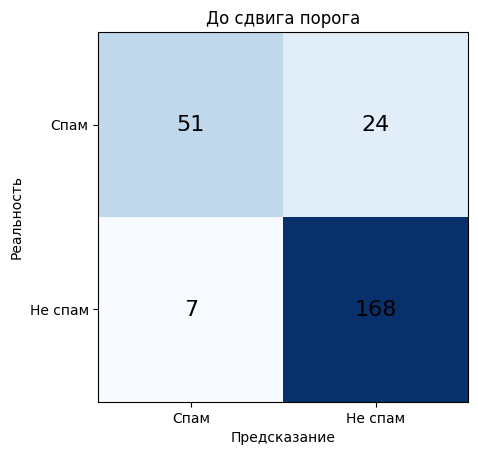

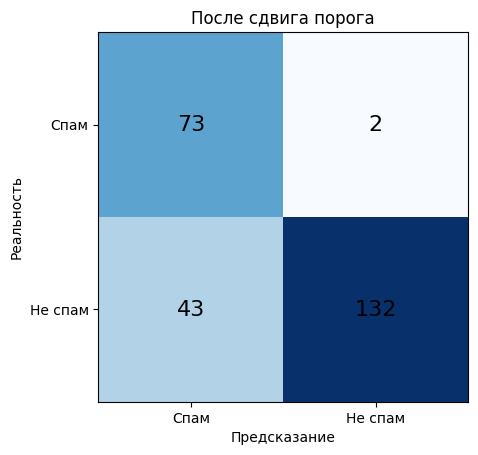

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def draw(cm, title):
    plt.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i][j], ha="center", va="center", fontsize=16)
    plt.xticks([0, 1], ["Спам", "Не спам"])
    plt.yticks([0, 1], ["Спам", "Не спам"])
    plt.xlabel("Предсказание")
    plt.ylabel("Реальность")
    plt.title(title)
    plt.show()

draw(np.array([[TP, FN], [FP, TN]]), "До сдвига порога")
draw(np.array([[TP2, FN2], [FP2, TN2]]), "После сдвига порога")